In [1]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

### To estimate the tail probability of $\mathcal{N}(0,1)$ for $P(X>5)$, we can draw samples from $\mathcal{N}(0,1)$ and keep only those that are $>5$. But such samples need to be 5 standard deviations from the mean $0$! These are very very rare occurences!

 ### Instead, we can use the exponential density truncated at 5 as the importance function and use importance sampling.

2.866515719235352e-07

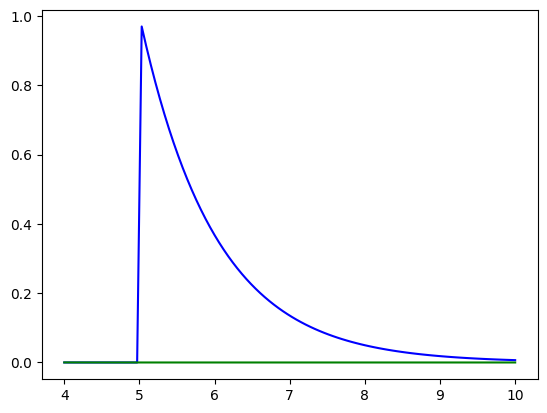

In [2]:
x = np.linspace(4, 10, 100)
plt.plot(x, stats.expon(loc=5).pdf(x), color='b')
plt.plot(x, stats.norm().pdf(x), color='g')


h_true =1 - stats.norm().cdf(5)
h_true

### Sampling directly from $\mathcal{N}(0,1)$.

In [3]:
n = 10000
y = stats.norm().rvs(n)
h_mc = 1.0/n * np.sum(y > 5)
# estimate and relative error
h_mc, np.abs(h_mc - h_true)/h_true

(0.0, 1.0)

### Importance sampling

In [4]:
n = 10000
y = stats.expon(loc=5).rvs(n)
h_is = 1.0/n * np.sum(stats.norm().pdf(y)/stats.expon(loc=5).pdf(y))
# estimate and relative error
h_is, np.abs(h_is- h_true)/h_true

(2.933070982373821e-07, 0.02321817483569307)